<a href="https://colab.research.google.com/github/A-Peoples/NFL_Play_Predictor/blob/main/NFL_Play_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Streamlit App that Predicts Best Play Type in Different Game Scenarios**

****

**Project Startdate: 3/22/26**

**Project Enddate: 6/5/26**
****

# **Goals:**

**1: Explore & Clean Dataset**

**2: Create Visualizations of Playcalling Variations for Article**

**3: Create Play Guesser with Different Model Types (only 25-26 season)**

**4: Port Model from Colab Notebook to Streamlit**

**5: Write & Publish Article**

**Importing Packages**

In [ ]:
!pip install sportsdataverse
!pip install xgboost==1.6.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 5.0 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 1.6.2
    Uninstalling xgboost-1.6.2:
      Successfully uninstalled xgboost-1.6.2


  Using cached xgboost-1.6.2-py3-none-manylinux2014_x86_64.whl.metadata (1.8 kB)
Using cached xgboost-1.6.2-py3-none-manylinux2014_x86_64.whl (255.9 MB)
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.2.0
    Uninstalling xgboost-3.2.0:
      Successfully uninstalled xgboost-3.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sportsdataverse 0.0.52 requires xgboost>=2.0.0, but you have xgboost 1.6.2 which is incompatible.


In [ ]:
#importing packages
import pandas as pd
import sportsdataverse as sdv
import numpy as np
import seaborn as sns
import os
import urllib.request
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from scipy.stats import t
import math

# **1: Explore & Clean Dataset**

In [ ]:
#pbp is base play-by-play dataset (2025)
pbp = sdv.nfl.load_nfl_pbp([2025], return_as_pandas=True)
pbp.columns.values

pbp[['total_home_score', 'posteam_score', 'home_score']]

,total_home_score,posteam_score,home_score
0,0.0,NaN,13
1,0.0,0.0,13
2,0.0,0.0,13
3,0.0,0.0,13
4,0.0,0.0,13
...,...,...,...
48766,13.0,13.0,13
48767,13.0,13.0,13
48768,13.0,13.0,13
48769,13.0,13.0,13


In [ ]:
pbp['play_type'].unique()

array([None, 'kickoff', 'run', 'pass', 'punt', 'no_play', 'field_goal',
       'extra_point', 'qb_spike', 'qb_kneel'], dtype=object)

In [ ]:
colors = pd.read_csv("https://raw.githubusercontent.com/A-Peoples/NFL_Team_Penalties/refs/heads/main/colors.csv")
colors = colors.loc[colors['team_abbr'].isin(pbp['posteam'].to_list())].reset_index()
names = pd.read_csv("https://raw.githubusercontent.com/A-Peoples/NFL_Team_Penalties/refs/heads/main/names.csv")

In [ ]:
pbp = pbp.loc[(pbp['posteam'].notna()) & (~pbp['play_type'].isin(['no_play', 'kickoff'])) & (~pbp['play_type'].isna())]
#adding new columns
pbp['posteam_score'] = np.where(pbp['posteam'] == pbp['home_team'], pbp['total_home_score'], pbp['total_away_score'])
pbp['defteam_score'] = np.where(pbp['defteam'] == pbp['away_team'], pbp['total_away_score'], pbp['total_home_score'])
#adding preplay score column
pbp['posteam_pre_score'] = pbp.groupby(['game_id'])['posteam_score'].shift(1, fill_value=0)
pbp['defteam_pre_score'] = pbp.groupby(['game_id'])['defteam_score'].shift(1, fill_value=0)
#adding posteam point differential column
pbp['posteam_pd'] = pbp['posteam_pre_score'] - pbp['defteam_pre_score']
#creating map to remap play_type column
pt_map = {
 'run': 0,
 'pass': 1,
 'field_goal': 2,
 'punt': 3,
 'extra_point': 4,
 'qb_spike': 5,
 'qb_kneel': 6}

pbp['play_type_remap'] = pbp['play_type'].map(pt_map)

#adding discrete numberical value corresponding to home and away teams
team_icon_remap = colors['team_abbr']
team_icon_remap = team_icon_remap.to_dict()

team_icon_remap = {v: k for k, v in team_icon_remap.items()}

pbp['posteam_num'] = pbp['posteam'].map(team_icon_remap)
pbp['defteam_num'] = pbp['defteam'].map(team_icon_remap)
#adding seperate game minutes and seconds for potential use
pbp['game_minutes'] = (pbp['game_seconds_remaining'] / 60).apply(math.floor)
pbp['game_minutes']

pbp['quarter_minutes'] = (pbp['quarter_seconds_remaining'] / 60).apply(math.floor)
pbp['quarter_minutes']

pbp['quarter_rseconds'] = pbp['quarter_seconds_remaining'] - (pbp['quarter_minutes'] * 60)

#creating a play_by_play dataset which only has passing and running plays
pr_pbp = pbp.loc[pbp['play_type_remap'] <= 1]
#creating a play_by_play dataset which only has passing, running, and field goal plays
prf_pbp = pbp.loc[pbp['play_type_remap'] <= 2]
#creating a play_by_play dataset which only has passing, running, and punt plays
prfp_pbp = pbp.loc[pbp['play_type_remap'] <= 3]

**Why the dictionary's values were reversed**

Every dictionary has **values (v)** and **keys (k)**. Every value has a corresponding key **(k:v)** and there can't be any duplicate keys, instead using the last repeated value.

When this line of code is written: **{v: k for k, v in team_icon_remap.items()}**, it creates a new dictionary where **values become keys** and vice versa. In this instance, creating a new numberical team value would result in NaNs since it would be looking for the numbers meant for remapping and trying to replace it with the team abbreviations. By reversing the dictionary, it would map correctly.

In [ ]:
team_values = pbp[['posteam', 'posteam_num']].drop_duplicates().sort_values(by='posteam_num', ascending=True)

In [ ]:
team_values.to_csv('team_values.csv')

# **2: Create Visualizations of Playcalling Variations for Article**

**Play Calling Down (Datasets Used: down_pbp, call_down_avg)**

/tmp/ipykernel_1995/3342339388.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  call_down_avg = down_pbp.groupby(down_pbp['time_bin']).agg({'play_type_remap': 'mean',


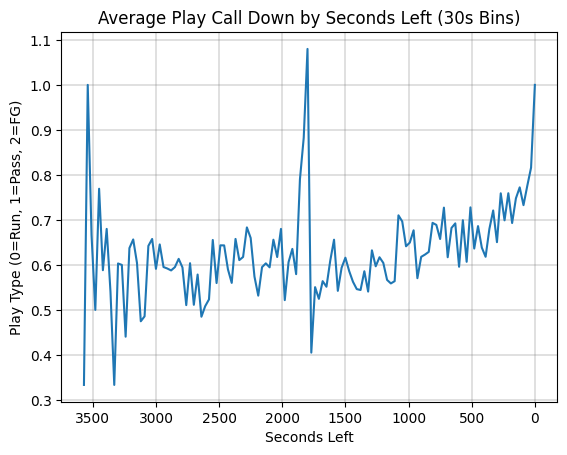

In [ ]:
#creating a play_by_play dataset which only includes plays where the offense is down before the game starts
down_pbp = pbp.loc[pbp['posteam_pre_score'] < pbp['defteam_pre_score']]
down_pbp = down_pbp.loc[down_pbp['play_type_remap'] <= 2]
bin_func = 3600
#creating bin list 60 minutes to 0 seconds in 30 second intervals
bin_list = []
while bin_func >= 0:
  bin_list.append(bin_func)
  bin_func -= 30

bin_list = sorted(bin_list)
#adding the second list when down into a bin
down_pbp['time_bin'] = pd.cut(down_pbp['game_seconds_remaining'], bins=bin_list)

#creating groupby to show the average type of play based on seconds left; 0=run, 1=pass, 2=field_goal
call_down_avg = down_pbp.groupby(down_pbp['time_bin']).agg({'play_type_remap': 'mean',
                                                                          'play_id': 'count'}).reset_index()

#taking the first value of the bins for charting
call_down_avg['time_bin'] = call_down_avg['time_bin'].apply(lambda x: x.left).astype(float)
call_down_avg = call_down_avg.sort_values(by="time_bin", ascending=False)
#graphing Average Play Call Down by Seconds Left (30s Bins)
f, ax = plt.subplots()
ax.plot(call_down_avg['time_bin'], call_down_avg['play_type_remap'])
ax.set_xlabel('Seconds Left')
ax.set_ylabel('Play Type (0=Run, 1=Pass, 2=FG)')
ax.set_title('Average Play Call Down by Seconds Left (30s Bins)')
ax.grid(True, color='grey', linewidth=0.35)

ax.invert_xaxis()

plt.show()

In [ ]:
call_down_avg

,time_bin,play_type_remap,play_id
119,3570.0,0.333333,3
118,3540.0,1.000000,2
117,3510.0,0.666667,3
116,3480.0,0.500000,8
115,3450.0,0.769231,13
...,...,...,...
4,120.0,0.772321,224
3,90.0,0.732759,348
2,60.0,0.775665,263
1,30.0,0.816176,272


In [ ]:
call_down_avg

,time_bin,play_type_remap,play_id
119,3570.0,0.333333,3
118,3540.0,1.000000,2
117,3510.0,0.666667,3
116,3480.0,0.500000,8
115,3450.0,0.769231,13
...,...,...,...
4,120.0,0.772321,224
3,90.0,0.732759,348
2,60.0,0.775665,263
1,30.0,0.816176,272


In [ ]:
#testing if the pre-check works
down_pbp[['game_id', 'posteam_score', 'defteam_score', 'posteam_pre_score', 'defteam_pre_score', 'field_goal_result', 'game_seconds_remaining']].to_csv('test.csv')

**Play Calling Up (Datasets Used: up_pbp, call_up_avg)**

/tmp/ipykernel_1995/942589677.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  call_up_avg = up_pbp.groupby(up_pbp['time_bin']).agg({'play_type_remap': 'mean',


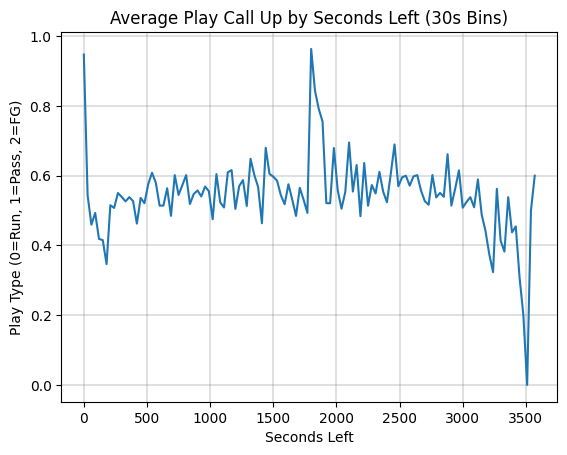

In [ ]:
#creating a play_by_play dataset which only includes plays where the offense is up before the play starts
up_pbp = pbp.loc[pbp['posteam_pre_score'] > pbp['defteam_pre_score']]
up_pbp = up_pbp.loc[up_pbp['play_type_remap'] <= 2]
bin_func = 3600

#creating bin list 60 minutes to 0 seconds in 30 second intervals
bin_list = []
while bin_func >= 0:
  bin_list.append(bin_func)
  bin_func -= 30

bin_list = sorted(bin_list)
#adding the second list when up into a bin
up_pbp['time_bin'] = pd.cut(up_pbp['game_seconds_remaining'], bins=bin_list)

#creating groupby to show the average type of play based on seconds left; 0=run, 1=pass, 2=field_goal
call_up_avg = up_pbp.groupby(up_pbp['time_bin']).agg({'play_type_remap': 'mean',
                                                                          'play_id': 'count'}).reset_index()
#taking the first value of the bins for charting
call_up_avg['time_bin'] = call_up_avg['time_bin'].apply(lambda x: x.left).astype(float)

#graphing Average Play Call Up by Seconds Left (30s Bins)
f, ax = plt.subplots()
ax.plot(call_up_avg['time_bin'], call_up_avg['play_type_remap'])
ax.set_xlabel('Seconds Left')
ax.set_ylabel('Play Type (0=Run, 1=Pass, 2=FG)')
ax.set_title('Average Play Call Up by Seconds Left (30s Bins)')
ax.grid(True, color='grey', linewidth=0.35)
plt.show()

**Average Playcalling from Every Team (Datasets Used: avg_play_type, colors, names, call_down_avg, pr_pbp)**

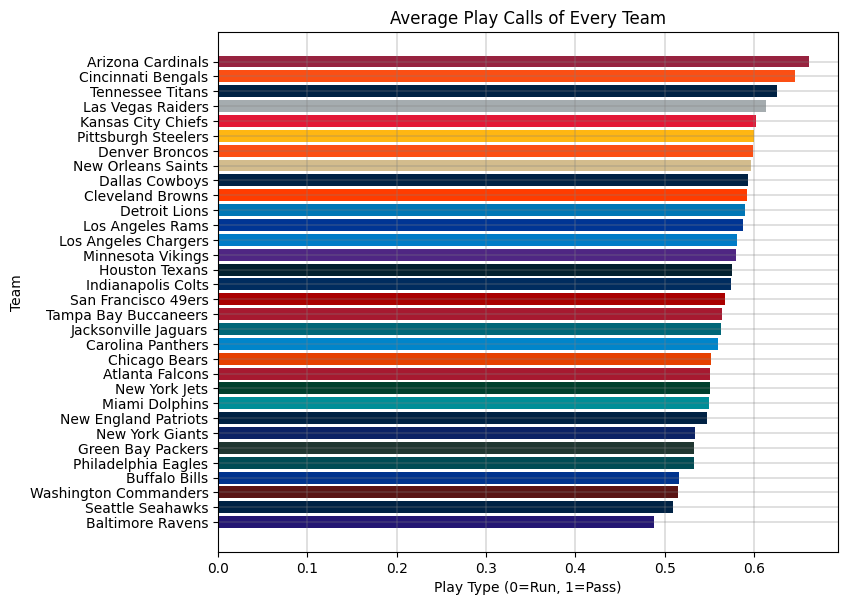

In [ ]:
colors = colors.loc[colors['team_abbr'].isin(pbp['posteam'].to_list())]
pbp['play_type_remap'].unique().tolist()


avg_play_type = pr_pbp.groupby('posteam').agg({'play_type_remap': 'mean'}).reset_index()
avg_play_type['colors'] = colors['team_color'].tolist()
avg_play_type['team_name'] = names['team_name'].tolist()
avg_play_type = avg_play_type.sort_values(by='play_type_remap', ascending=True)

#graphing Average Play Call Up by Seconds Left (30s Bins)
f, ax = plt.subplots(figsize=(8, 6.75))
ax.barh(avg_play_type['team_name'], avg_play_type['play_type_remap'], color=avg_play_type['colors'].tolist())
ax.set_xlabel('Play Type (0=Run, 1=Pass)')
ax.set_ylabel('Team')
ax.set_title('Average Play Calls of Every Team')
ax.grid(True, color='grey', linewidth=0.35)
plt.show()

In [ ]:
pr_pbp['play_type_remap'].mean()

np.float64(0.5699145200415848)

<Axes: ylabel='team_name'>

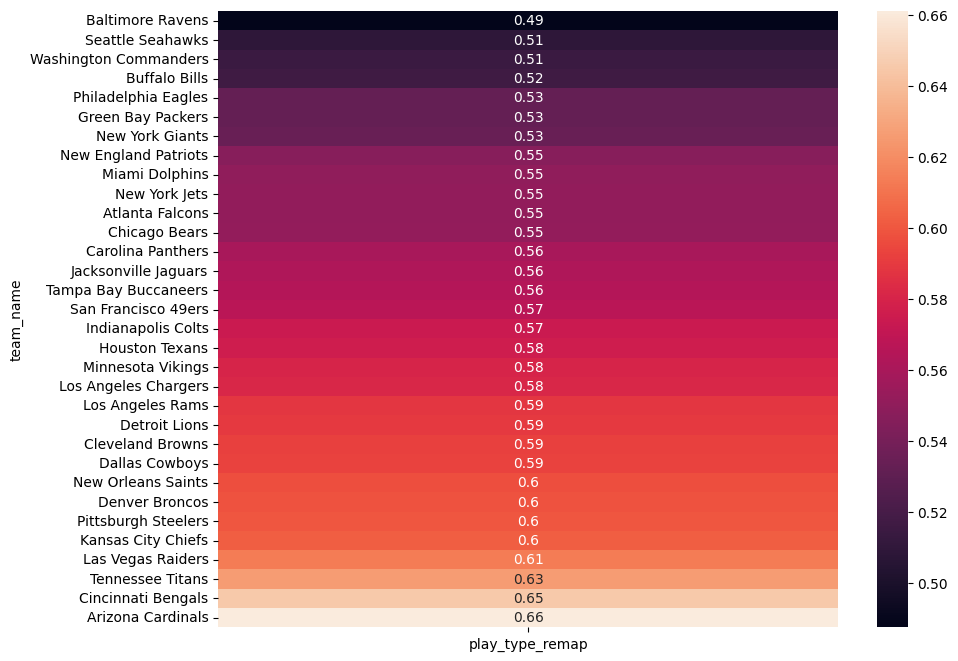

In [ ]:
heat_map = avg_play_type.set_index(avg_play_type['team_name'])[['play_type_remap']]
plt.figure(figsize=(10,8))
sns.heatmap(heat_map, annot=True)

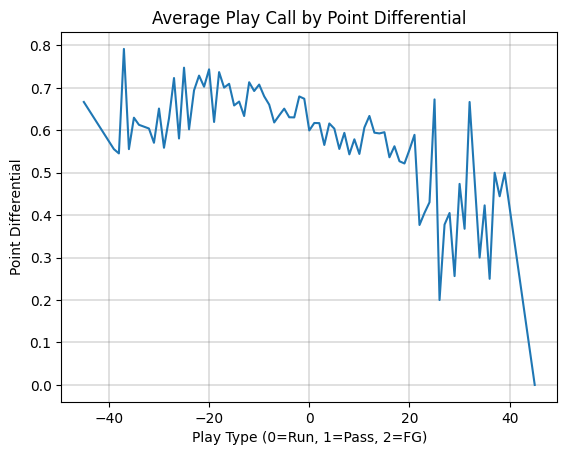

In [ ]:
pd_gb = prf_pbp.groupby(['posteam_pd']).agg({"play_type_remap": 'mean'}).reset_index()
pd_gb

f, ax = plt.subplots()
ax.plot(pd_gb['posteam_pd'], pd_gb['play_type_remap'])
ax.set_xlabel('Play Type (0=Run, 1=Pass, 2=FG)')
ax.set_ylabel('Point Differential')
ax.set_title('Average Play Call by Point Differential')
ax.grid(True, color='grey', linewidth=0.35)
plt.show()

# **3: Create Play Guesser with Different Model Types (only 25-26 season)**

In [ ]:
#Creating a Logistic Regression Model

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

**Definition of Advanced Stats**

**Success%** measures offensive efficiency based on if a play gained enough yardage to keep the offense on the field based on **down and distance**.  For example, an offense might want to gain 3-4 yards on a 1st and 10. If they gained 30% of the yards, **that would be considered a success**. However, if the offense does not gain the sufficient amount of yards, **that play would not be considered successful.**

*More info about Success Rate:* https://www.actionnetwork.com/ncaaf/success-rate-definition


**Expected Points Added (EPA)** is a metric measuring a plays impact based on **its scoring chance before and after the play.** EPA number ranges from **-3 to 7 points.** Like Success%, it's not just based on yards gained, it also factors the **in-game situation.** For example, a 5 yard gain 95 yards from the endzone has a lower EPA than a 5 yard gain on 2nd and goal.

*More info about EPA:* https://bestballstats.com/expected-points-added-a-full-explanation/


**Logistic Regression**

**Logistic Regression**

**Logistic Regression** is a **supervised machine learning model** that classifies values based on other values. It specifically values **binary classification**, which is a question that can be one of two categories, such as 0/1, Yes/No, True/False, etc. Instead of a straight line, it uses the sigmoid function, **σ=((1)/(1+e^-x)),** to calculate values. It is characterized by its S shape. It heavily penalizes confident but wrong predictions, with lower log likelihood showing better model performance. Logistic regression models struggle when the data is a heavily varied dataset that doesn't follow a linear pattern.

*More Info on Sigmoid Function:* https://machinelearningmastery.com/a-gentle-introduction-to-sigmoid-function/


**Why the number 42 is used for Random State**

**Random state** is an **arbitrary number** fed into the program to set a specific set of randomness, acting as a **"seed"**. Specifying the specific number guarantees that the **same rows would be kept** every time this block of code is run. The number 42 doesn't actually mean anything, and it can be any number that the coder wanted. The reason 42 is popular is because of a literary reference that became an inside joke in the data science community. In Douglas Adams ' *The Hitchhiker's Guide to the Galaxy,* a supercomputer that created Earth named Deep Thought calculated that the answer to everything in life was 42.

**Thoughts at the time**

Originally, my idea was to use logistic regression like my NFL game prediction model in 2024. At the moment, it made sense since it would be predicting pass or run. Unfortunately, the final model finished with an 49% accuracy. The reason why the model tested poorly was the dataset's complexity. As stated previously, logistic models struggle with overly complex datasets. However, even if the model didn't do well with passing and rushing, it would only hold the projects back due to its forced simplicity. In the NFL, there are more plays than passing and rushing, for example, field goals. Since Logistic Regression uses binary classification, it can't handle more than a run or a pass. While pivoting to use binary logistic regression was a potential option, I instead opted to use a tree model for the first time.


In [ ]:
test_dataset = prfp_pbp[['posteam', 'posteam_num', 'defteam', 'defteam_num', 'posteam_pd', 'posteam_score', 'yardline_100', 'play_type_remap',
                         'success', 'epa', 'first_down', 'qtr', 'game_seconds_remaining', 'down', 'ydstogo', 'posteam_timeouts_remaining', 'defteam_timeouts_remaining']].dropna()
#choosing original values for dataset (possession team, defensive team, point-differential, timeouts, yards till endzone, quarter, seconds left, down, and yards until first down)
X = test_dataset[['posteam_num', 'defteam_num', 'posteam_pd', 'yardline_100',
                          'qtr', 'game_seconds_remaining', 'down', 'ydstogo', 'posteam_timeouts_remaining','defteam_timeouts_remaining',  'play_type_remap']]
#value that will be predicted (numerical play type)
y = test_dataset['play_type_remap']

#train test splits splits  the dataset into testing and training datasets
#test size value is the amount of the dataset is separated for testing/predicting. In this case, 20% (0.2) of the dataset is kept for predicting.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_train

lr = LogisticRegression()
#fitting the model with the training data
lr.fit(X_train, y_train)

#predicting the values from test dataset
y_pred = lr.predict(X_test)

#classification report prints the classification metrics how how a dataset tested on the
print("Logistic Regression Score:\n\n" + classification_report(y_test, y_pred))

Logistic Regression Score:

              precision    recall  f1-score   support

           0       0.63      0.32      0.43      2976
           1       0.57      0.86      0.68      3919
           2       0.00      0.00      0.00       239
           3       0.08      0.01      0.02       403

    accuracy                           0.58      7537
   macro avg       0.32      0.30      0.28      7537
weighted avg       0.55      0.58      0.53      7537



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
X = test_dataset[['posteam_num', 'defteam_num', 'posteam_pd', 'yardline_100',
                          'qtr', 'game_seconds_remaining', 'down', 'ydstogo', 'posteam_timeouts_remaining','defteam_timeouts_remaining',  'play_type_remap']]
X.to_csv('test_dataset.csv')
X

,posteam_num,defteam_num,posteam_pd,yardline_100,qtr,game_seconds_remaining,down,ydstogo,posteam_timeouts_remaining,defteam_timeouts_remaining,play_type_remap
2,0,22,0.0,78.0,1.0,3596.0,1.0,10.0,3.0,3.0,0
3,0,22,0.0,75.0,1.0,3558.0,2.0,7.0,3.0,3.0,1
4,0,22,0.0,64.0,1.0,3520.0,1.0,10.0,3.0,3.0,1
5,0,22,0.0,75.0,1.0,3477.0,2.0,21.0,3.0,3.0,0
6,0,22,0.0,77.0,1.0,3434.0,3.0,23.0,3.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...
48763,21,27,-16.0,88.0,4.0,90.0,2.0,4.0,0.0,0.0,1
48764,21,27,-16.0,83.0,4.0,72.0,1.0,10.0,0.0,0.0,1
48767,21,27,-16.0,62.0,4.0,39.0,1.0,10.0,0.0,0.0,1
48768,21,27,-16.0,53.0,4.0,20.0,2.0,1.0,0.0,0.0,1


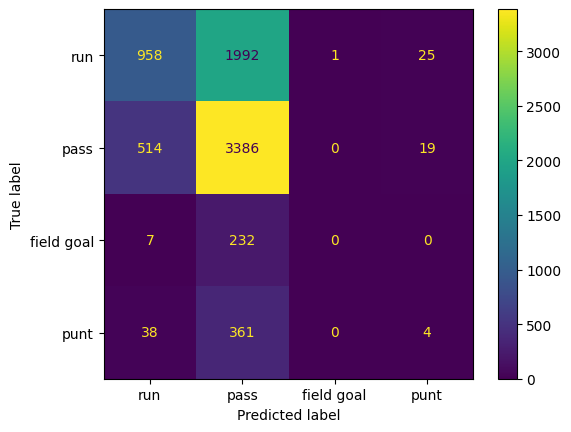

In [ ]:
cm_lm = confusion_matrix(y_test, y_pred)
disp =ConfusionMatrixDisplay(confusion_matrix=cm_lm, display_labels=['run', 'pass', 'field goal', 'punt'])
disp.plot()
plt.show()

**Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

**Decision Tree Classifier**

A **Decision Tree Classifier** is a **supervised machine learning** algorithm that categorizes data based on set rules or **nodes**, creating a tree like structure. There rules are generated based on what the computer thinks is the best and split based on feature importance. It uses a "greedy" approach where it chooses the one that splits the data the best. While this seems helpful to choose seperate, if the tree becomes too complex, it will "overfit" itself where instead of memorizing trends, it will memorize the training data.

In [ ]:
test_dataset
features = ['yardline_100', 'down', 'ydstogo', 'posteam_num', 'defteam_num', 'game_seconds_remaining', 'posteam_pd', 'posteam_timeouts_remaining', 'defteam_timeouts_remaining']
X = test_dataset[features]
scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)

y = test_dataset['play_type_remap']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
dtc = DecisionTreeClassifier()

dtc.fit(X_train, y_train)

y_pred = dtc.predict(X_test)

In [ ]:
cm_lm = confusion_matrix(y_test, y_pred)
disp =ConfusionMatrixDisplay(confusion_matrix=cm_lm, display_labels=['run', 'pass', 'field goal', 'punt'])
disp.plot()
plt.show()

In [ ]:
print("Decision Tree Model Score:\n\n" + classification_report(y_test, y_pred))

In [ ]:
imp = pd.DataFrame(dtc.feature_importances_, index=X.columns)

imp_fix = imp.sort_values(by=0, ascending=False)#.transpose().reset_index()

imp_fix

**Random Forest Model**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
dtc_re2 = RandomForestClassifier(max_depth=13, criterion='entropy', class_weight='balanced', n_estimators=100, random_state=42)

dtc_re2.fit(X_train, y_train)

y_pred = dtc_re2.predict(X_test)


print("Random Forest Model Score:\n\n" + classification_report(y_test, y_pred))

Random Forest Model Score:

              precision    recall  f1-score   support

           0       0.60      0.74      0.66      2976
           1       0.76      0.61      0.68      3919
           2       0.82      0.92      0.87       239
           3       0.91      0.96      0.93       403

    accuracy                           0.69      7537
   macro avg       0.77      0.81      0.78      7537
weighted avg       0.71      0.69      0.69      7537



In [ ]:
imp = pd.DataFrame(dtc_re2.feature_importances_, index=X_test.columns)

imp_fix = imp.sort_values(by=0, ascending=False)#.transpose().reset_index()

imp_fix

,0
down,0.487674
yardline_100,0.300716
ydstogo,0.059312
game_seconds_remaining,0.043766
posteam_timeouts_remaining,0.034417
posteam_pd,0.024079
defteam_timeouts_remaining,0.018441
posteam_num,0.016060
defteam_num,0.015535


# **4: Port Model from Colab Notebook to Streamlit**

In [ ]:
!pip install streamlit

In [ ]:
test_dataset[['yardline_100', 'down', 'ydstogo', 'posteam_num', 'defteam_num', 'game_seconds_remaining', 'posteam_pd', 'play_type_remap']].to_csv("test_dataset.csv")

In [ ]:
#importing packages
import pandas as pd
import sportsdataverse as sdv
import numpy as np
import matplotlib.pyplot as plt
import streamlit as st
#modeling packages
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
st.set_page_config(page_title='NFL Penalty Charting', layout="wide")
@st.cache_data()

def load_data():
  test_dataset = pd.read_csv('https://raw.githubusercontent.com/A-Peoples/NFL_Play_Predictor/refs/heads/main/datasets/test_dataset.csv')
  team_values = pd.read_csv('https://raw.githubusercontent.com/A-Peoples/NFL_Play_Predictor/refs/heads/main/datasets/team_values.csv')

  return test_dataset, team_values
st.header("NFL Play Type Predictor")
test_dataset, team_values = load_data()
test_dataset = test_dataset[['posteam_num', 'defteam_num', 'down', 'ydstogo', 'posteam_pd','yardline_100', 'game_seconds_remaining',
                             'play_type_remap', 'posteam_timeouts_remaining', 'defteam_timeouts_remaining']]

col1, col2 , col3, col4, col5 = st.columns(5)

with col1:
  home_team = st.selectbox("Home Team", team_values['posteam'].unique())
  spec_ht = team_values.loc[team_values['posteam'] == home_team]
  home_team_num = spec_ht['posteam_num'].iloc[0]
  #st.write(str(home_team_num))

  away_team = st.selectbox("Away Team", team_values['posteam'].unique())
  spec_at = team_values.loc[team_values['posteam'] == away_team]
  away_team_num = spec_at['posteam_num'].iloc[0]
  #st.write(str(away_team_num))
with col2:
  p_diff = st.number_input("Point Differential", step=1)
  yt_ez = st.slider("Yards Til Goaline", 0, 100, 75)

with col3:
  quarter = st.selectbox("Quarter", range(1, 5))
  minutes = st.slider("Minutes in Quarter", 0, 15, 15)
  seconds = st.slider("Seconds in Quarter", 0, 59, 0)
  if minutes == 15:
    seconds = 0
  game_sec = (3600 - (quarter * 900 - 900)) - (900 - (minutes * 60 + seconds))
  #st.write(str(game_sec))
with col4:
  down = st.selectbox("Down", range(1, 5))
  ydstogo = st.selectbox("Yards To Go", range(1, 43), 9)
  if down == 1:
    ydstogo = 10
with col5:
  h_timeouts = st.selectbox("Home Team Timeouts", range(0, 4), 3)
  a_timeouts = st.selectbox("Away Team Timeouts", range(0, 4), 3)
column_dataset = test_dataset.loc[(((test_dataset['posteam_pd'] - p_diff).isin(range(-5, 5))) &
                                   ((test_dataset['ydstogo'] - ydstogo).isin(range(-5, 5))) & ((test_dataset['game_seconds_remaining'] - game_sec).isin(range(-60, 61)) & (test_dataset['down'] == down) &
                                   (test_dataset['yardline_100'] - yt_ez).isin(range(-10, 10))) &
                                   (test_dataset['posteam_timeouts_remaining'] == h_timeouts) & (test_dataset['defteam_timeouts_remaining'] == a_timeouts))].reset_index(drop=True)

#st.dataframe(test_dataset, use_container_width=True)


features = ['posteam_num', 'defteam_num', 'down', 'ydstogo', 'posteam_pd','yardline_100', 'game_seconds_remaining', 'posteam_timeouts_remaining', 'defteam_timeouts_remaining']
labels = ['play_type_remap']

X = column_dataset[features]
y = column_dataset[labels]
def play_proba():
  if X.empty:
    st.write('No Rows Found')
    return


  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.01, random_state=42)

  scaler = StandardScaler()
  scaler.fit(X_train)
  X_train_scaled = scaler.transform(X_train)

  dtc_re2 = RandomForestClassifier(max_depth=13, criterion='entropy', class_weight='balanced', n_estimators=100, random_state=42)
  dtc_re2.fit(X_train, y_train.values.ravel())
  #training
  user_checks = np.array([[home_team_num, away_team_num, down, ydstogo, p_diff, yt_ez, game_sec, h_timeouts, a_timeouts]])
  prob = dtc_re2.predict_proba(user_checks)[0]
  classes = dtc_re2.classes_

  st.write('Play Probabilities')
  st.write(str(X.shape))

  prob_df = pd.DataFrame({'Play_Type': classes, 'Probability': prob})

  pt_map = {
 'run': 0,
 'pass': 1,
 'field_goal': 2,
 'punt': 3,
 'extra_point': 4,
 'qb_spike': 5,
 'qb_kneel': 6}
  pt_map = {v: k for k, v in pt_map.items()}
  prob_df['Play_Type'] = prob_df['Play_Type'].map(pt_map)
  st.dataframe(prob_df, use_container_width=True)
if st.button('Generate Prediction'):
  play_proba()

2026-06-04 00:23:13.006 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 00:23:13.007 No runtime found, using MemoryCacheStorageManager
2026-06-04 00:23:13.009 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 00:23:13.010 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 00:23:13.012 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 00:23:13.017 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 00:23:13.018 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 00:23:13.019 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 00:23:13.020 Thread 'MainThread':